# ConvLSTM

In [1]:
# Import packages
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Level 1 data
ds_level1 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train"
)

# Convert to pandas DataFrame
df_level1 = ds_level1.to_pandas()

In [3]:
# -------------------------------------------------
# 1. Prepare Data
# -------------------------------------------------

df = df_level1.copy()

# Ensure correct date ordering
df["Date"] = pd.to_datetime(df["Date"], format='%d/%m/%Y')
df = df.sort_values("Date").reset_index(drop=True)

# Drop Date column
price_df = df.drop(columns=["Date"])

prices = price_df.values  # shape (T, 224)

# Log transform
log_prices = np.log(prices)

# -------------------------------------------------
# 2. Train / Validation Split (chronological)
# -------------------------------------------------

T = len(log_prices)

train_data = log_prices[:int(T * 0.75), :]
val_data = log_prices[int(T * 0.75):, :]

In [4]:
# Extract Tenor and Maturity from column names
def parse_col(col):
    tenor = float(col.split(";")[0].split(":")[1])
    maturity = float(col.split(";")[1].split(":")[1])
    return tenor, maturity

col_info = [parse_col(c) for c in price_df.columns]
tenors = sorted(set(t for t, m in col_info))
maturities = sorted(set(m for t, m in col_info))

T = len(df)
H = len(maturities)
W = len(tenors)

# Build 3D tensor (T, H, W)
surface = np.zeros((T, H, W))

for j, (tenor, maturity) in enumerate(col_info):
    i_m = maturities.index(maturity)
    i_t = tenors.index(tenor)
    surface[:, i_m, i_t] = price_df.iloc[:, j].values

# Log transform
surface = np.log(surface)

In [5]:
split_idx = int(T * 0.75)

train_data = surface[:split_idx]
val_data = surface[split_idx:]

# Scale per node
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data.reshape(split_idx, -1))
val_scaled = scaler.transform(val_data.reshape(T - split_idx, -1))

train_scaled = train_scaled.reshape(split_idx, H, W)
val_scaled = val_scaled.reshape(T - split_idx, H, W)

In [6]:
WINDOW = 30
HORIZON = 6

def create_windows(data):
    X, Y = [], []
    for t in range(WINDOW, len(data) - HORIZON):
        X.append(data[t-WINDOW:t])
        Y.append(data[t:t+HORIZON])
    return np.array(X), np.array(Y)

X_train, Y_train = create_windows(train_scaled)
X_val, Y_val = create_windows(val_scaled)

# Add channel dimension for ConvLSTM
X_train = torch.tensor(X_train[:, :, None, :, :], dtype=torch.float32)
Y_train = torch.tensor(Y_train[:, :, None, :, :], dtype=torch.float32)
X_val = torch.tensor(X_val[:, :, None, :, :], dtype=torch.float32)
Y_val = torch.tensor(Y_val[:, :, None, :, :], dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=16, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=16, shuffle=False)

In [7]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_dim = hidden_dim
        self.conv = nn.Conv2d(
            input_dim + hidden_dim,
            4 * hidden_dim,
            kernel_size,
            padding=padding
        )

    def forward(self, x, h_prev, c_prev):
        combined = torch.cat([x, h_prev], dim=1)
        conv_out = self.conv(combined)
        cc_i, cc_f, cc_o, cc_g = torch.split(conv_out, self.hidden_dim, dim=1)

        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)

        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c
    
class ConvLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=24, kernel_size=3, horizon=6):
        super().__init__()
        self.cell = ConvLSTMCell(input_dim, hidden_dim, kernel_size)
        self.output_conv = nn.Conv2d(hidden_dim, 1, kernel_size=1)
        self.horizon = horizon
        self.hidden_dim = hidden_dim

    def forward(self, x):
        B, T, C, H, W = x.shape

        h = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=x.device)

        # Encode past sequence
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)

        outputs = []

        # Decode future sequence
        input_future = x[:, -1]  # last observed surface

        for _ in range(self.horizon):
            h, c = self.cell(input_future, h, c)
            out = self.output_conv(h)
            outputs.append(out.unsqueeze(1))
            input_future = out

        return torch.cat(outputs, dim=1)

In [8]:
model = ConvLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

best_val = np.inf
patience = 10
counter = 0

for epoch in range(200):

    # Train
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_convlstm.pt")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

model.load_state_dict(torch.load("best_convlstm.pt"))

Epoch 0 | Train 0.776134 | Val 0.534022
Epoch 1 | Train 0.436094 | Val 0.353569
Epoch 2 | Train 0.297519 | Val 0.347152
Epoch 3 | Train 0.291927 | Val 0.293974
Epoch 4 | Train 0.239580 | Val 0.278443
Epoch 5 | Train 0.246185 | Val 0.246994
Epoch 6 | Train 0.236421 | Val 0.256635
Epoch 7 | Train 0.234030 | Val 0.242082
Epoch 8 | Train 0.227163 | Val 0.227427
Epoch 9 | Train 0.218699 | Val 0.231084
Epoch 10 | Train 0.217469 | Val 0.217742
Epoch 11 | Train 0.207940 | Val 0.217434
Epoch 12 | Train 0.205395 | Val 0.215007
Epoch 13 | Train 0.203482 | Val 0.229517
Epoch 14 | Train 0.213411 | Val 0.213370
Epoch 15 | Train 0.196998 | Val 0.229529
Epoch 16 | Train 0.208855 | Val 0.200668
Epoch 17 | Train 0.178908 | Val 0.202470
Epoch 18 | Train 0.181411 | Val 0.214059
Epoch 19 | Train 0.194275 | Val 0.191899
Epoch 20 | Train 0.180065 | Val 0.218560
Epoch 21 | Train 0.185368 | Val 0.191615
Epoch 22 | Train 0.165634 | Val 0.204874
Epoch 23 | Train 0.164213 | Val 0.187324
Epoch 24 | Train 0.169666 

<All keys matched successfully>

In [9]:
def reconstruct_prices_convlstm(pred_scaled):
    """
    pred_scaled: (N, H, W) in scaled log space
    """
    N = pred_scaled.shape[0]

    # reshape to 2D for scaler inverse
    pred_scaled_2d = pred_scaled.reshape(N, -1)

    log_prices = scaler.inverse_transform(pred_scaled_2d)
    log_prices = log_prices.reshape(N, H, W)

    return np.exp(log_prices)


def compute_surface_metrics_convlstm(model, loader, eps=1e-8):
    model.eval()

    mse_list = []
    mape_list = []

    with torch.no_grad():
        for xb, yb in loader:

            pred = model(xb).numpy()   # (B, HORIZON, 1, 16, 14)
            true = yb.numpy()

            B, HORIZON, _, HH, WW = pred.shape

            pred = pred.reshape(-1, HH, WW)
            true = true.reshape(-1, HH, WW)

            pred_prices = reconstruct_prices_convlstm(pred)
            true_prices = reconstruct_prices_convlstm(true)

            mse = np.mean((pred_prices - true_prices)**2)
            mape = np.mean(
                np.abs((pred_prices - true_prices) /
                       (true_prices + eps))
            )

            mse_list.append(mse)
            mape_list.append(mape)

    rmse = np.sqrt(np.mean(mse_list))
    mape = 100 * np.mean(mape_list)

    return rmse, mape

convlstm_train_rmse, convlstm_train_mape = compute_surface_metrics_convlstm(model, train_loader)
convlstm_val_rmse, convlstm_val_mape = compute_surface_metrics_convlstm(model, val_loader)

print("ConvLSTM Train RMSE:", convlstm_train_rmse)
print("ConvLSTM Train MAPE:", convlstm_train_mape)

print("ConvLSTM Val RMSE:", convlstm_val_rmse)
print("ConvLSTM Val MAPE:", convlstm_val_mape)

ConvLSTM Train RMSE: 0.0075724563
ConvLSTM Train MAPE: 2.5785408
ConvLSTM Val RMSE: 0.0071687438
ConvLSTM Val MAPE: 3.0439825


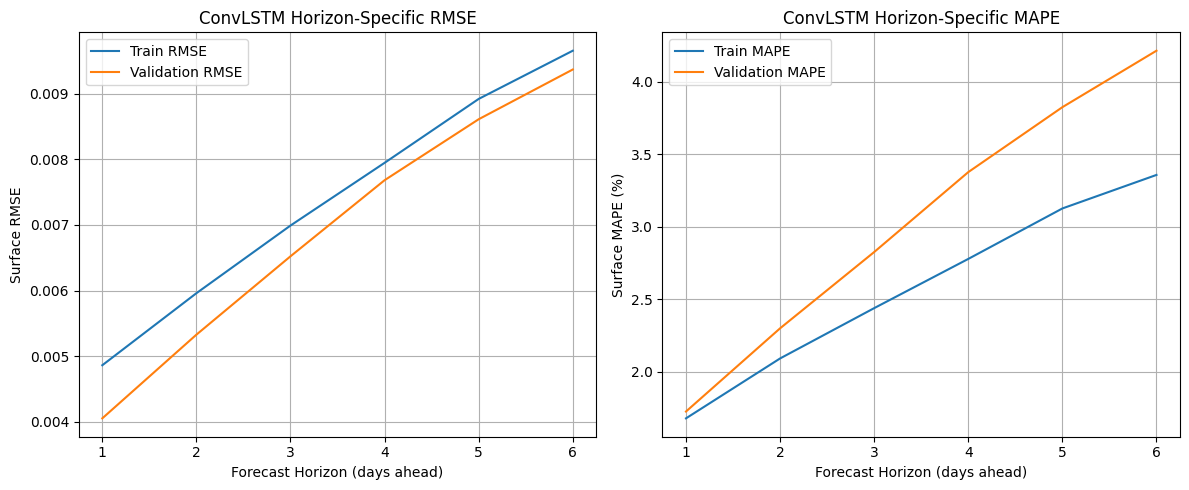

In [10]:
def compute_horizon_metrics_convlstm(model, loader, eps=1e-8):
    """
    Returns:
        rmse_per_h: (HORIZON,)
        mape_per_h: (HORIZON,)
    """

    model.eval()

    with torch.no_grad():

        # Collect errors per horizon
        horizon_mse = {}
        horizon_mape = {}

        for xb, yb in loader:

            pred = model(xb).numpy()     # (B, H, 1, 16, 14)
            true = yb.numpy()

            B, HORIZON, _, HH, WW = pred.shape

            for h in range(HORIZON):

                pred_h = pred[:, h, 0]   # (B, 16, 14)
                true_h = true[:, h, 0]

                # reshape to 2D for scaler
                pred_h = pred_h.reshape(-1, HH, WW)
                true_h = true_h.reshape(-1, HH, WW)

                pred_prices = reconstruct_prices_convlstm(pred_h)
                true_prices = reconstruct_prices_convlstm(true_h)

                mse = np.mean((pred_prices - true_prices)**2)
                mape = np.mean(
                    np.abs((pred_prices - true_prices) /
                           (true_prices + eps))
                )

                horizon_mse.setdefault(h, []).append(mse)
                horizon_mape.setdefault(h, []).append(mape)

        rmse_per_h = np.array([
            np.sqrt(np.mean(horizon_mse[h])) for h in range(HORIZON)
        ])

        mape_per_h = np.array([
            100 * np.mean(horizon_mape[h]) for h in range(HORIZON)
        ])

    return rmse_per_h, mape_per_h

convlstm_train_rmse_h, convlstm_train_mape_h = \
    compute_horizon_metrics_convlstm(model, train_loader)

convlstm_val_rmse_h, convlstm_val_mape_h = \
    compute_horizon_metrics_convlstm(model, val_loader)

import matplotlib.pyplot as plt
import numpy as np

horizon = np.arange(1, len(convlstm_train_rmse_h) + 1)

plt.figure(figsize=(12,5))

# RMSE
plt.subplot(1,2,1)
plt.plot(horizon, convlstm_train_rmse_h, label="Train RMSE")
plt.plot(horizon, convlstm_val_rmse_h, label="Validation RMSE")
plt.xlabel("Forecast Horizon (days ahead)")
plt.ylabel("Surface RMSE")
plt.title("ConvLSTM Horizon-Specific RMSE")
plt.legend()
plt.grid(True)

# MAPE
plt.subplot(1,2,2)
plt.plot(horizon, convlstm_train_mape_h, label="Train MAPE")
plt.plot(horizon, convlstm_val_mape_h, label="Validation MAPE")
plt.xlabel("Forecast Horizon (days ahead)")
plt.ylabel("Surface MAPE (%)")
plt.title("ConvLSTM Horizon-Specific MAPE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()